### Core functions

In [1]:
import os
import warnings
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import tensorflow as tf
import src.auxiliar as aux
import src.entropy_estimator as entropy_estimator
from sklearn.neighbors import KNeighborsClassifier

SMALL_SIZE = 10+2
MEDIUM_SIZE = 14+2
BIGGER_SIZE = 18+216

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

reds = aux.CustomCmap([60/255,60/255,60/255], [196/255,60/255,60/255])
greens = aux.CustomCmap([0.1, 0.3, 0.1], [0.1, 0.8, 0.1])
blues = aux.CustomCmap([60/255,60/255,60/255], [45/255,159/255,255/255])
teals = aux.CustomCmap([60/255,60/255,60/255], [0/255,200/255,130/255])

class_colors = ['#2D9FFF', '#FF5154', '#E5D352', '#00C882']
model_colors = ['#2D9FFF', '#FF5154', '#E5D352', '#00C882']

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2025-02-02 22:37:43.984863: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-02 22:37:44.083406: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738553864.117735    7455 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738553864.128286    7455 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-02 22:37:44.205923: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Num GPUs Available:  1


### Example 5: Make Classification

In [2]:
def generate_dataset(num_samples=10000, n_features=32, rel_features=8, n_classes=10, test_ratio=0.5, seed=None):
	x_data, y_data = datasets.make_classification(n_samples=num_samples,
											      n_features=n_features, 
												  n_informative=rel_features, 
												  n_redundant=rel_features, 
												  n_repeated=0, 
												  n_classes=n_classes, 
												  n_clusters_per_class=4, 
												  shuffle=True, 
												  flip_y=0,
												  random_state=seed)
	x_train, x_test = x_data[:round(num_samples*test_ratio)], x_data[round(num_samples*test_ratio):] 
	y_train, y_test = y_data[:round(num_samples*test_ratio)], y_data[round(num_samples*test_ratio):] 
	# Normalization
	scaler = StandardScaler()
	x_train = scaler.fit_transform(x_train)
	x_test = scaler.transform(x_test)
	x_data = scaler.transform(x_data)
	# LDA to help models and speed things up.
	lda = LinearDiscriminantAnalysis(n_components=min(n_features, n_classes-1))
	lda.fit(x_train, y_train)
	x_data = lda.transform(x_data)
	x_train = lda.transform(x_train)
	x_test = lda.transform(x_test)
	return x_data, y_data, x_train, y_train, x_test, y_test

In [3]:
def estimate_classificability(x_data, y_data):
	with np.errstate(divide='ignore', invalid='ignore'):
		cs = []
		#for k in [8,16,32,64]:
		#	cs.append(entropy_estimator.classificability_estimator(x_data, y_data, k_neighbors=k, num_workers=32))
		for r in [entropy_estimator.density_dist(x_data, d=0.003)]:
			cs.append(entropy_estimator.classificability_estimator(x_data, y_data, distance_threshold=r, num_workers=32))
		return cs

In [4]:
def train_mlp(x_train, y_train, x_test, y_test, num_classes, num_models=10):

	def create_model(num_classes):

		model = tf.keras.Sequential([
			tf.keras.layers.Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
			tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
			tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
			tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
			tf.keras.layers.Dense(num_classes)
		])
		return model

	train_acc, test_acc = [], []
	for _ in range(num_models):
		# Prepare the data
		train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(10000).batch(64)
		test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(6250)

		# Define model
		model = create_model(num_classes)
		model.compile(
			optimizer='adam',
			loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
			metrics=['accuracy'],
		)

		# Train the model
		history = model.fit(train_ds, epochs=15, verbose=0, validation_data=test_ds)
		train_acc.append(history.history['accuracy'])
		test_acc.append(history.history['val_accuracy'])

		del model
		del train_ds
		del test_ds
		del history

	return np.stack(train_acc), np.stack(test_acc)

In [2]:
num_samples = 25000
n_features = [32,64,128,256,512] * 5
n_rel_features = [8,16,32,64,128] * 5
n_classes = 5 * [4] + 5 * [8] + 5 * [16] + 5 * [32] + 5 * [64]
num_models = 5
data_path = './data/large_classification'
seeds = [42,3,14,15,92,65,35,89,79,32]
num_dataset_samples = len(seeds)

In [10]:
for n_f, n_rf, n_c in tqdm(zip(n_features, n_rel_features, n_classes)):
	# Estimate and train
	classificabilities, train_accuracies, test_accuracies = [], [], []
	for i in range(num_dataset_samples):
		x_data, y_data, x_train, y_train, x_test, y_test = generate_dataset(num_samples=num_samples, n_features=n_f, rel_features=n_rf, n_classes=n_c, test_ratio=0.5, seed=seeds[i])
		cs = estimate_classificability(x_data, y_data)
		classificabilities.append(cs)
		del x_data
		del y_data
		del x_train
		del y_train
		del x_test
		del y_test 
	np.save(os.path.join(data_path, f'classificabilities_r_f_{n_f}_rf_{n_rf}_c_{n_c}.npy'), classificabilities)

0it [00:00, ?it/s]2025-01-27 14:22:36,681	INFO worker.py:1821 -- Started a local Ray instance.
25it [38:09, 91.60s/it] 


(raylet) [2025-01-27 18:01:36,765 E 24320 24320] (raylet) node_manager.cc:3069: 5 Workers (tasks / actors) killed due to memory pressure (OOM), 0 Workers crashed due to other reasons at node (ID: 3ece3474f7d78d7ee5471071115700cc18744fdf04a0d400533720b3, IP: 192.168.1.236) over the last time period. To see more information about the Workers killed on this node, use `ray logs raylet.out -ip 192.168.1.236`
(raylet) 
(raylet) Refer to the documentation on how to address the out of memory issue: https://docs.ray.io/en/latest/ray-core/scheduling/ray-oom-prevention.html. Consider provisioning more memory on this node or reducing task parallelism by requesting more CPUs per task. To adjust the kill threshold, set the environment variable `RAY_memory_usage_threshold` when starting Ray. To disable worker killing, set the environment variable `RAY_memory_monitor_refresh_ms` to zero.
(raylet) 
(raylet) [2025-01-27 18:02:36,766 E 24320 24320] (raylet) node_manager.cc:3069: 6 Workers (tasks / actors

In [7]:
for n_f, n_rf, n_c in tqdm(zip(n_features, n_rel_features, n_classes)):

	# Estimate and train
	train_accuracies, test_accuracies = [], []
	for i in range(num_dataset_samples):
		x_data, y_data, x_train, y_train, x_test, y_test = generate_dataset(num_samples=num_samples, n_features=n_f, rel_features=n_rf, n_classes=n_c, test_ratio=0.5, seed=seeds[i])
		train_acc, test_acc = train_mlp(x_train, y_train, x_test, y_test, n_c, num_models=num_models)
		train_accuracies.append(train_acc)
		test_accuracies.append(test_acc)
	train_accuracies = np.stack(train_accuracies)
	test_accuracies = np.stack(test_accuracies)
	del x_data, 
	del y_data
	del x_train
	del y_train
	del x_test
	del y_test 
	
	# Save data
	os.makedirs(data_path, exist_ok=True)
	np.save(os.path.join(data_path, f'train_f_{n_f}_rf_{n_rf}_c_{n_c}.npy'), train_accuracies)
	np.save(os.path.join(data_path, f'test_f_{n_f}_rf_{n_rf}_c_{n_c}.npy'), test_accuracies)

0it [00:00, ?it/s]I0000 00:00:1737748751.707205    4225 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10234 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1737748752.474726    5554 service.cc:148] XLA service 0x7ee838016f10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1737748752.474890    5554 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2025-01-24 14:59:12.508521: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1737748752.613109    5554 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-01-24 14:59:12.830456: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in 

In [34]:
for n_f, n_rf, n_c in tqdm(zip(n_features, n_rel_features, n_classes)):

	# Estimate and train
	train_accuracies, test_accuracies = [], []
	for i in range(num_dataset_samples):
		x_data, y_data, x_train, y_train, x_test, y_test = generate_dataset(num_samples=num_samples, n_features=n_f, rel_features=n_rf, n_classes=n_c, test_ratio=0.5, seed=seeds[i])
		#clf = KNeighborsClassifier(n_neighbors=64)
		clf = RandomForestClassifier(n_estimators=100, max_depth=5)
		clf.fit(x_train, y_train)
		train_acc = clf.score(x_train, y_train)
		test_acc = clf.score(x_test, y_test)
		train_accuracies.append(train_acc)
		test_accuracies.append(test_acc)
	train_accuracies = np.stack(train_accuracies)
	test_accuracies = np.stack(test_accuracies)
	del x_data, 
	del y_data
	del x_train
	del y_train
	del x_test
	del y_test 
	
	# Save data
	os.makedirs(data_path, exist_ok=True)
	np.save(os.path.join(data_path, f'rfc_train_f_{n_f}_rf_{n_rf}_c_{n_c}.npy'), train_accuracies)
	np.save(os.path.join(data_path, f'rfc_test_f_{n_f}_rf_{n_rf}_c_{n_c}.npy'), test_accuracies)

25it [08:43, 20.95s/it]


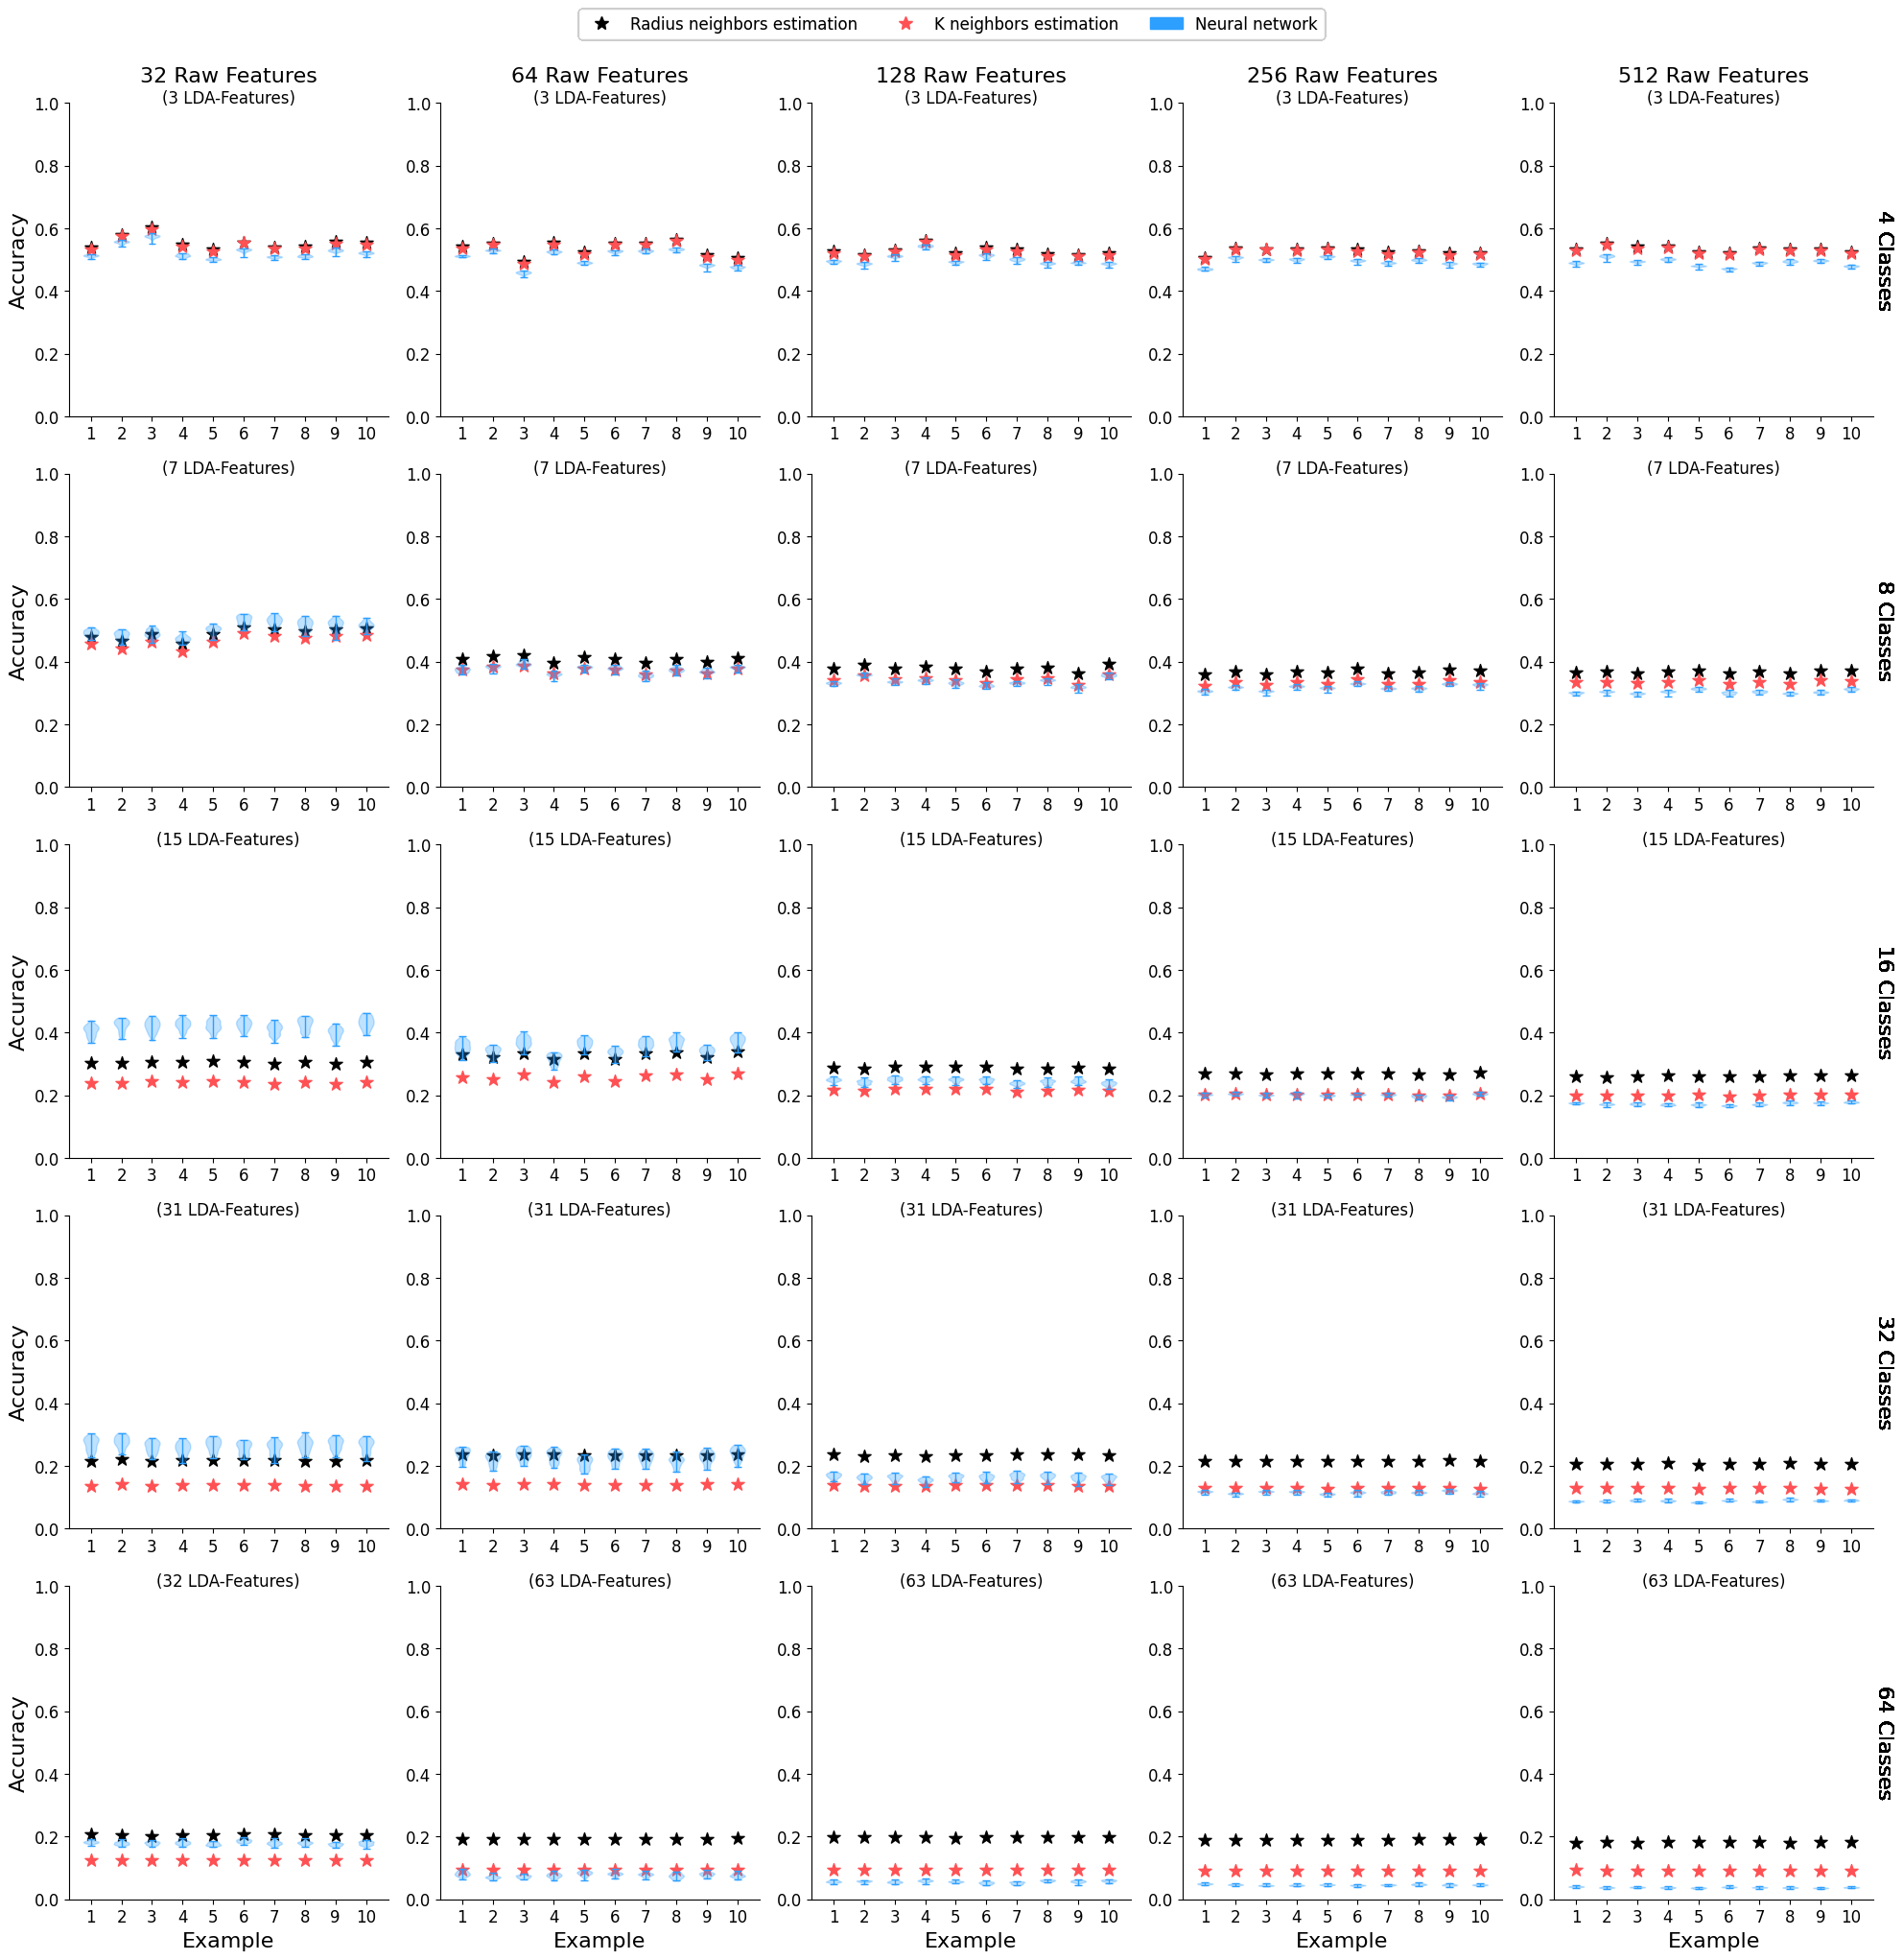

In [3]:
fig, ax = plt.subplots(5,5, figsize=(5*4,5*4))
pos = np.arange(10) * 2
#lims = [[0.4,0.7],[0.25,0.65],[0.1,0.5],[0.0,0.3],[0.0,0.3]]
lims = [[0,1],[0,1],[0,1],[0,1],[0,1]]

for idx, (n_f, n_rf, n_c) in enumerate(zip(n_features, n_rel_features, n_classes)):

	classificabilities = np.load(os.path.join(data_path, f'classificabilities_r_f_{n_f}_rf_{n_rf}_c_{n_c}.npy'))
	train_accuracies = np.load(os.path.join(data_path, f'train_f_{n_f}_rf_{n_rf}_c_{n_c}.npy'))
	test_accuracies = np.load(os.path.join(data_path, f'test_f_{n_f}_rf_{n_rf}_c_{n_c}.npy'))

	c_pos = pos
	
	ax[idx//5, idx%5].scatter(c_pos, classificabilities[:,0], color='k', marker='*', s=100)

	classificabilities = np.load(os.path.join(data_path, f'classificabilities_f_{n_f}_rf_{n_rf}_c_{n_c}.npy'))
	ax[idx//5, idx%5].scatter(c_pos, classificabilities[:,2], color=model_colors[1], marker='*', s=100)

	#ax[idx//5, idx%5].scatter(c_pos, classificabilities[:,1], color='r', marker='*', s=100)
	#ax[idx//5, idx%5].scatter(c_pos, classificabilities[:,2], color='g', marker='*', s=100)
	#ax[idx//5, idx%5].scatter(c_pos, classificabilities[:,3], color='b', marker='*', s=100)
	#ax[idx//5, idx%5].scatter(c_pos, classificabilities[:,4], color='c', marker='*', s=100)

	parts = ax[idx//5, idx%5].violinplot([test_accuracies[i,:,-10:].reshape(-1) for i in range(10)], positions=pos, widths=1)
	for pc in parts['bodies']:
		pc.set_facecolor(model_colors[0])
		pc.set_edgecolor(model_colors[0])
		pc.set_alpha(0.3)
	for partname in ('cbars','cmins','cmaxes'):
		vp = parts[partname]
		vp.set_edgecolor(model_colors[0])
		vp.set_linewidth(1)

	for i, f, rf in zip(range(5), [32,64,128,256,512], [8,16,32,64,128]):
		ax[0, i].set_title(f'{f} Raw Features', fontsize=MEDIUM_SIZE)
		ax[4, i].set_xlabel('Example')

	ax[idx//5, idx%5].set_ylim(lims[idx//5][0],lims[idx//5][1])

	aux_ax = ax[idx//5, idx%5].twiny()
	aux_ax.set_xlabel(f'({min(n_f,n_c-1)} LDA-Features)', fontsize=SMALL_SIZE, labelpad=0)
	aux_ax.spines['top'].set_visible(False)
	aux_ax.spines['right'].set_visible(False)
	aux_ax.spines['bottom'].set_visible(False)
	aux_ax.spines['left'].set_visible(False)
	aux_ax.set_xticks([])
	aux_ax.set_xticklabels([])
	ax[4, i].set_xlabel('Example')

	for i, c in zip(range(5), [4, 8, 16, 32, 64]):
		aux_ax = ax[i, 4].twinx()
		aux_ax.set_ylabel(f'{c} Classes', fontsize=MEDIUM_SIZE, rotation=270, labelpad=15)
		aux_ax.spines['top'].set_visible(False)
		aux_ax.spines['right'].set_visible(False)
		aux_ax.spines['bottom'].set_visible(False)
		aux_ax.spines['left'].set_visible(False)
		aux_ax.set_yticks([])
		aux_ax.set_yticklabels([])
		ax[i, 0].set_ylabel('Accuracy')

	for i in range(25):
		ax[i//5, i%5].set_xticks(np.arange(10)*2, np.arange(10)+1)
		ax[i//5, i%5].spines['top'].set_visible(False)
		ax[i//5, i%5].spines['right'].set_visible(False)

	from matplotlib.lines import Line2D
	from matplotlib.patches import Patch

	legend_elements = [Line2D([], [], color='k', marker='*', linestyle='None', markersize=10, label='Radius neighbors estimation'), 
					   Line2D([], [], color=model_colors[1], marker='*', linestyle='None', markersize=10, label='K neighbors estimation'), 
					   Patch(facecolor=model_colors[0], edgecolor=model_colors[0], label='Neural network')]
	legend = fig.legend(handles=legend_elements, ncols=3, bbox_to_anchor=(0.5, 1.025), loc='upper center')

plt.tight_layout()
plt.savefig('./images/dataset_madelon.png', dpi=300, bbox_extra_artists=(legend,), bbox_inches='tight')
plt.show()

In [10]:
1/64

0.015625